# Coffee Sales Data Analysis ☕
## Project Overview
This project analyzes coffee vending machine sales data to discover trends, popular products, payment behavior, and peak sales hours.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
sns.set_style('whitegrid')

## Load Dataset

In [2]:
data = pd.read_csv('index.csv')
data.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


## Dataset Information

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1133 entries, 0 to 1132
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1133 non-null   object 
 1   datetime     1133 non-null   object 
 2   cash_type    1133 non-null   object 
 3   card         1044 non-null   object 
 4   money        1133 non-null   float64
 5   coffee_name  1133 non-null   object 
dtypes: float64(1), object(5)
memory usage: 53.2+ KB


## Check Missing Values

In [4]:
data.isnull().sum()

date            0
datetime        0
cash_type       0
card           89
money           0
coffee_name     0
dtype: int64

## Convert Date Columns

In [5]:
data['date'] = pd.to_datetime(data['date'])
data['datetime'] = pd.to_datetime(data['datetime'])

## Feature Engineering

In [6]:
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day_name()
data['hour'] = data['datetime'].dt.hour
data.head()

,date,datetime,cash_type,card,money,coffee_name,month,day,hour
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte,3,Friday,10
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate,3,Friday,12
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate,3,Friday,12
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano,3,Friday,13
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte,3,Friday,13


## Coffee Sales Distribution

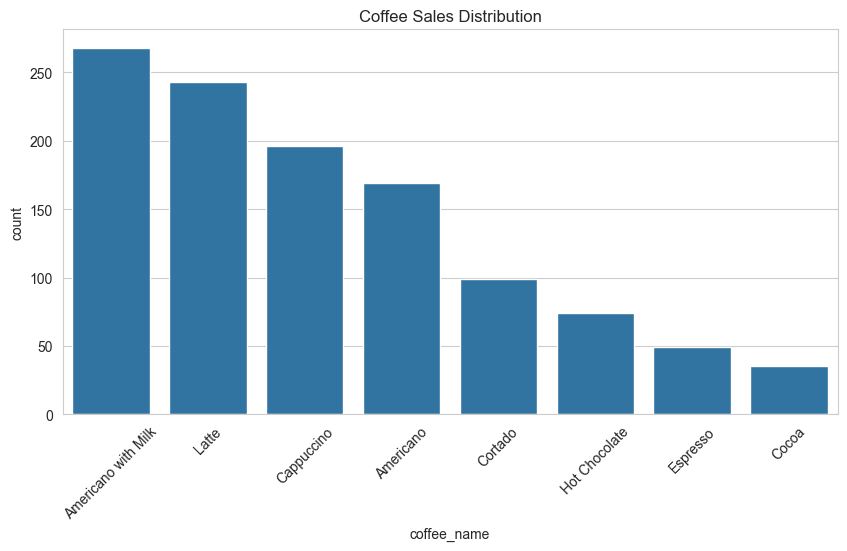

In [7]:
plt.figure(figsize=(10,5))
sns.countplot(data=data, x='coffee_name', order=data['coffee_name'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Coffee Sales Distribution')
plt.show()

## Revenue by Coffee Type

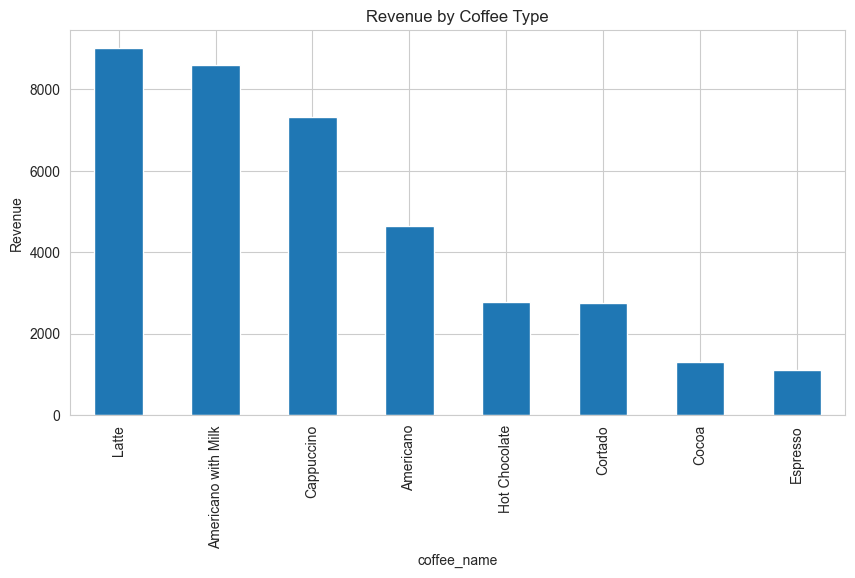

In [8]:
revenue = data.groupby('coffee_name')['money'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,5))
revenue.plot(kind='bar')
plt.title('Revenue by Coffee Type')
plt.ylabel('Revenue')
plt.show()

## Sales by Day

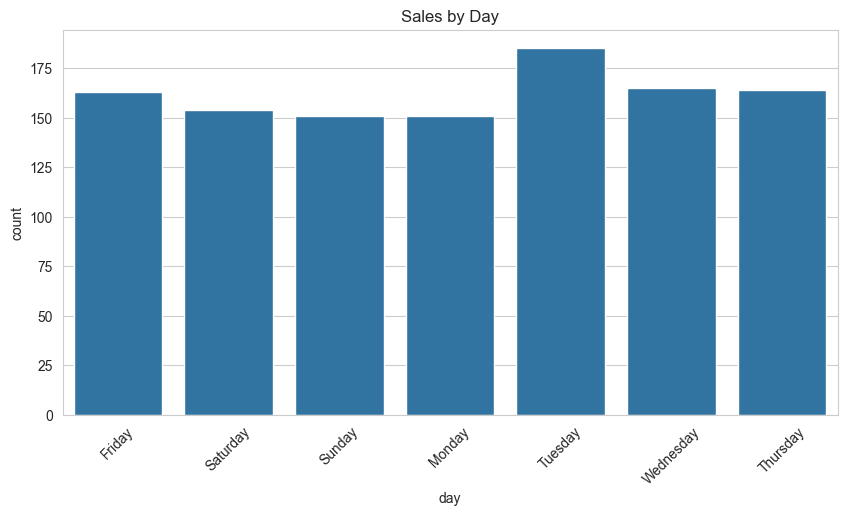

In [9]:
plt.figure(figsize=(10,5))
sns.countplot(data=data, x='day')
plt.xticks(rotation=45)
plt.title('Sales by Day')
plt.show()

## Hourly Sales Analysis

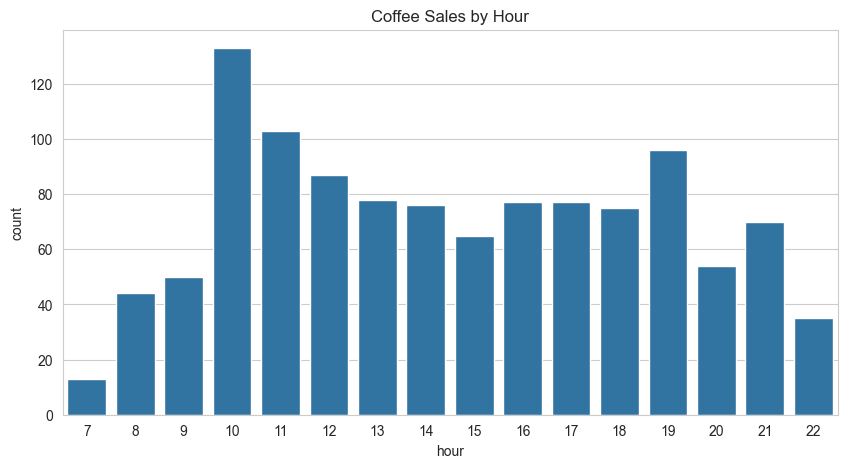

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(data=data, x='hour')
plt.title('Coffee Sales by Hour')
plt.show()

## Payment Method Distribution

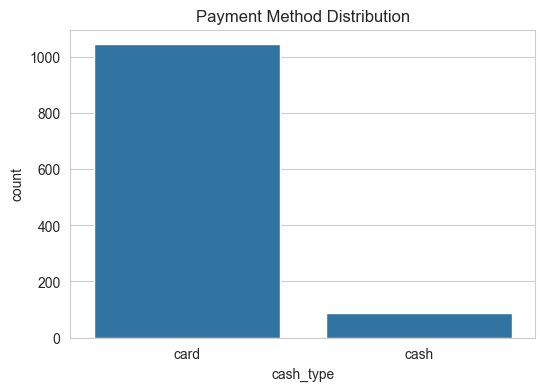

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=data, x='cash_type')
plt.title('Payment Method Distribution')
plt.show()

## Machine Learning Model

In [12]:
X = pd.get_dummies(data[['coffee_name','cash_type','hour']], drop_first=True)
y = data['money']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)
print('MSE:', mean_squared_error(y_test, pred))
print('R2:', r2_score(y_test, pred))

MSE: 3.3346965635319097
R2: 0.8208738739005287


## Conclusion
- Identify most popular coffee
- Understand payment patterns
- Discover peak hours of coffee sales
- Use machine learning to model sales behavior